In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    roc_auc_score, roc_curve, average_precision_score,
    precision_recall_curve, confusion_matrix, classification_report
)

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")


Using device: cpu
PyTorch version: 2.11.0+cpu


#### 1. Load the dataset

In [2]:
# Load Data
DATA_PATH = "../../data/processed/splitteddataset"
train_df = pd.read_csv(f"{DATA_PATH}/lepto_monthly_train.csv", parse_dates=["YearMonth"])
test_df  = pd.read_csv(f"{DATA_PATH}/lepto_monthly_test.csv",  parse_dates=["YearMonth"])

train_df["District"] = train_df["District"].astype("category")
test_df["District"]  = test_df["District"].astype("category")

# Encode District + risk rate
le = LabelEncoder()
train_df["District_enc"] = le.fit_transform(train_df["District"])
test_df["District_enc"]  = le.transform(test_df["District"])

district_risk_rate = train_df.groupby("District", observed=False)["RiskLabel"].mean()
train_df["District_risk_rate"] = train_df["District"].map(district_risk_rate).astype(float)
test_df["District_risk_rate"]  = test_df["District"].map(district_risk_rate).astype(float)

print(f"Train: {train_df.shape}  |  Test: {test_df.shape}")
print(f"Districts: {train_df['District'].nunique()}  |  Months per district: {train_df.groupby('District').size().iloc[0]}")


Train: (3900, 56)  |  Test: (1200, 56)
Districts: 25  |  Months per district: 156


#### 2. Build District-level Sequences via Sliding Window

 - For each district, sort by YearMonth and create overlapping windows of SEQ_LEN months.
 - The label for each window is the last month.

In [3]:
SEQ_LEN = 12  # 12 months = 1 full annual disease cycle

## Static - dont change month wise
STATIC_COLS = ["District_enc", "District_risk_rate",
               "MRiceArea", "MRiceYield", "SRiceArea", "SRiceYield",
               "Population", "Households",
               "BIO2", "BIO3", "BIO4", "BIO13", "BIO14", "BIO15", "BIO16", "BIO17", "BIO18", "BIO19",
               "Pop_per_Household"]


SEQUENCE_COLS = [c for c in train_df.columns
                 if c not in STATIC_COLS + ["District", "RiskLabel", "YearMonth", "Month", "District_enc", "District_risk_rate",
                                            "MRiceArea", "MRiceYield", "SRiceArea", "SRiceYield",
                                            "Population", "Households",
                                            "BIO2", "BIO3", "BIO4", "BIO13", "BIO14", "BIO15", "BIO16", "BIO17", "BIO18", "BIO19",
                                            "Pop_per_Household"]]

print(f"Sequence features ({len(SEQUENCE_COLS)}): {SEQUENCE_COLS}")
print(f"Static features  ({len(STATIC_COLS)}): {STATIC_COLS}")


Sequence features (33): ['Precipitation_mm', 'Temp_Min_C', 'Temp_Max_C', 'Soil_Moisture_0_7cm', 'mean_temp', 'Precipitation_mm_lag1', 'Precipitation_mm_lag2', 'Precipitation_mm_lag3', 'Temp_Min_C_lag1', 'Temp_Min_C_lag2', 'Temp_Min_C_lag3', 'Temp_Max_C_lag1', 'Temp_Max_C_lag2', 'Temp_Max_C_lag3', 'Soil_Moisture_0_7cm_lag1', 'Soil_Moisture_0_7cm_lag2', 'Soil_Moisture_0_7cm_lag3', 'Precipitation_mm_roll3_mean', 'Precipitation_mm_roll6_mean', 'Soil_Moisture_0_7cm_roll3_mean', 'Soil_Moisture_0_7cm_roll6_mean', 'Month_sin', 'Month_cos', 'MRice_x_Precip', 'SRice_x_Precip', 'Temp_Range', 'Precip_vs_norm', 'Precip_anomaly', 'Waterlog_index', 'Heat_Moisture', 'HR_lag1', 'HR_lag2', 'HR_roll3']
Static features  (19): ['District_enc', 'District_risk_rate', 'MRiceArea', 'MRiceYield', 'SRiceArea', 'SRiceYield', 'Population', 'Households', 'BIO2', 'BIO3', 'BIO4', 'BIO13', 'BIO14', 'BIO15', 'BIO16', 'BIO17', 'BIO18', 'BIO19', 'Pop_per_Household']


#### 3. Test/Train  Split

In [4]:
def build_sequences(df, seq_len, sequence_cols, static_cols):
    X_seq, X_stat, y_out, idx_out = [], [], [], []
    for district, grp in df.groupby("District", observed=True):
        grp = grp.sort_values("YearMonth").reset_index(drop=True)
        seq_vals  = grp[sequence_cols].values.astype(np.float32)
        stat_vals = grp[static_cols].values.astype(np.float32)
        labels    = grp["RiskLabel"].values
        orig_idx  = grp.index.tolist()

        for i in range(seq_len - 1, len(grp)):
            X_seq.append(seq_vals[i - seq_len + 1 : i + 1])   # (seq_len, n_seq_feats)
            X_stat.append(stat_vals[i])                         # static at prediction month
            y_out.append(labels[i])
            idx_out.append(orig_idx[i])

    return (np.array(X_seq, dtype=np.float32),
            np.array(X_stat, dtype=np.float32),
            np.array(y_out,  dtype=np.float32),
            np.array(idx_out))

X_tr_seq, X_tr_stat, y_tr, tr_idx = build_sequences(train_df, SEQ_LEN, SEQUENCE_COLS, STATIC_COLS)
X_te_seq, X_te_stat, y_te, te_idx = build_sequences(test_df,  SEQ_LEN, SEQUENCE_COLS, STATIC_COLS)

print(f"\nSequence tensors - Train: {X_tr_seq.shape}  |  Test: {X_te_seq.shape}")
print(f"Static tensors   - Train: {X_tr_stat.shape}  |  Test: {X_te_stat.shape}")
print(f"Labels           - Train: {y_tr.shape}        |  Test: {y_te.shape}")
print(f"Class balance (train) - 0: {(y_tr==0).sum()}  1: {(y_tr==1).sum()}")



Sequence tensors - Train: (3625, 12, 33)  |  Test: (925, 12, 33)
Static tensors   - Train: (3625, 19)  |  Test: (925, 19)
Labels           - Train: (3625,)        |  Test: (925,)
Class balance (train) - 0: 1885  1: 1740


#### 4. Feature scaling

In [5]:
# 3. Scale Features (fit only on train)
scaler_seq  = StandardScaler()
scaler_stat = StandardScaler()

n_tr, seq_len, n_seq_feats = X_tr_seq.shape
X_tr_seq_flat = X_tr_seq.reshape(-1, n_seq_feats)
X_te_seq_flat = X_te_seq.reshape(-1, n_seq_feats)

X_tr_seq_flat = scaler_seq.fit_transform(X_tr_seq_flat)
X_te_seq_flat = scaler_seq.transform(X_te_seq_flat)

X_tr_seq = X_tr_seq_flat.reshape(n_tr, seq_len, n_seq_feats)
X_te_seq = X_te_seq_flat.reshape(X_te_seq.shape)

X_tr_stat = scaler_stat.fit_transform(X_tr_stat)
X_te_stat = scaler_stat.transform(X_te_stat)

print("Scaling complete.")
print(f"  Sequence feature dim : {n_seq_feats}")
print(f"  Static feature dim : {X_tr_stat.shape[1]}")


Scaling complete.
  Sequence feature dim : 33
  Static feature dim : 19


#### 5. Modeling - Bi-LSTM + Temporal Attention (ConvLSTM)

In [6]:
class TemporalAttention(nn.Module):
    def __init__(self, hidden_dim, dropout=0.3):
        super().__init__()
        self.attn = nn.Linear(hidden_dim, 1)
        self.dropout = nn.Dropout(dropout) # Attention dropout added

    def forward(self, lstm_out):
        scores = self.attn(lstm_out)           
        weights = torch.softmax(scores, dim=1) 
        weights = self.dropout(weights) # Apply dropout to attention weights
        context = (weights * lstm_out).sum(dim=1)  
        return context, weights.squeeze(-1)

class LeptoLSTM_v2(nn.Module):
    def __init__(self, seq_input_dim, static_input_dim, hidden_dim=128, lstm_layers=2, dropout=0.3):
        super().__init__()
        self.conv = nn.Conv1d(in_channels=seq_input_dim, out_channels=seq_input_dim * 2, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.conv_dropout = nn.Dropout(dropout)

        self.lstm = nn.LSTM(
            input_size=seq_input_dim * 2,
            hidden_size=hidden_dim,
            num_layers=lstm_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout
        )
        bi_dim = hidden_dim * 2
        self.layer_norm = nn.LayerNorm(bi_dim) # LayerNorm added after LSTM

        self.attention = TemporalAttention(bi_dim, dropout=dropout)

        self.static_branch = nn.Sequential(
            nn.Linear(static_input_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 32),
            nn.ReLU()
        )

        self.head = nn.Sequential(
            nn.Linear(bi_dim + 32, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(dropout / 2),
            nn.Linear(64, 1)
        )

    def forward(self, x_seq, x_stat):
        x_seq_c = x_seq.transpose(1, 2)
        x_seq_c = self.conv(x_seq_c)
        x_seq_c = self.relu(x_seq_c)
        x_seq_c = self.conv_dropout(x_seq_c)
        
        x_seq_lstm = x_seq_c.transpose(1, 2)
        lstm_out, _ = self.lstm(x_seq_lstm)
        
        # Apply LayerNorm
        lstm_out = self.layer_norm(lstm_out)
        
        context, _ = self.attention(lstm_out)
        static_out  = self.static_branch(x_stat)
        combined    = torch.cat([context, static_out], dim=1)
        return self.head(combined)


#### 6. Model-Training

In [7]:
class FocalLossBinary(nn.Module):
    def __init__(self, alpha=0.5, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.bce = nn.BCEWithLogitsLoss(reduction='none')
    def forward(self, logits, targets):
        bce_loss = self.bce(logits, targets)
        probs = torch.sigmoid(logits)
        p_t = probs * targets + (1 - probs) * (1 - targets)
        alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)
        focal_loss = alpha_t * ((1 - p_t) ** self.gamma) * bce_loss
        return focal_loss.mean()


def make_loader(X_seq, X_stat, y, batch_size=64, shuffle=False):
    ds = TensorDataset(
        torch.tensor(X_seq,  dtype=torch.float32),
        torch.tensor(X_stat, dtype=torch.float32),
        torch.tensor(y,      dtype=torch.float32).unsqueeze(1)
    )
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)


def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0
    for x_seq, x_stat, y_b in loader:
        x_seq, x_stat, y_b = x_seq.to(device), x_stat.to(device), y_b.to(device)
        optimizer.zero_grad()
        loss = criterion(model(x_seq, x_stat), y_b)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # gradient clipping
        optimizer.step()
        total_loss += loss.item() * x_seq.size(0)
    return total_loss / len(loader.dataset)


def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for x_seq, x_stat, y_b in loader:
            x_seq, x_stat, y_b = x_seq.to(device), x_stat.to(device), y_b.to(device)
            loss = criterion(model(x_seq, x_stat), y_b)
            total_loss += loss.item() * x_seq.size(0)
    return total_loss / len(loader.dataset)


def predict_proba(model, X_seq, X_stat, batch_size=256):
    model.eval()
    all_probs = []
    loader = make_loader(X_seq, X_stat, np.zeros(len(X_seq)), batch_size=batch_size, shuffle=False)
    with torch.no_grad():
        for x_seq, x_stat, _ in loader:
            logits = model(x_seq.to(device), x_stat.to(device))
            all_probs.append(torch.sigmoid(logits).cpu().numpy())
    return np.concatenate(all_probs).flatten()


#### 7. Cross-Validation with TimeSeriesSplit

In [8]:
n_districts = train_df["District"].nunique()
tscv = TimeSeriesSplit(n_splits=5, gap=n_districts)

BATCH_SIZE   = 32
N_EPOCHS     = 200
LR           = 3e-4
PATIENCE     = 25

criterion  = FocalLossBinary(alpha=0.5, gamma=2.0)


cv_aucs = []

print("=" * 60)
print("CROSS-VALIDATION (5-Fold TimeSeriesSplit)")
print("=" * 60)

for fold_i, (tr_idx_cv, val_idx_cv) in enumerate(tscv.split(X_tr_seq, y_tr)):
    tr_loader  = make_loader(X_tr_seq[tr_idx_cv],  X_tr_stat[tr_idx_cv],  y_tr[tr_idx_cv],  BATCH_SIZE, shuffle=True)
    val_loader = make_loader(X_tr_seq[val_idx_cv], X_tr_stat[val_idx_cv], y_tr[val_idx_cv], BATCH_SIZE, shuffle=False)

    model = LeptoLSTM_v2(
        seq_input_dim=X_tr_seq.shape[2],
        static_input_dim=X_tr_stat.shape[1]
    ).to(device)

    optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=8, factor=0.5)

    best_val_loss = float('inf')
    best_weights  = None
    patience_ctr  = 0

    for epoch in range(N_EPOCHS):
        tr_loss  = train_epoch(model, tr_loader,  criterion, optimizer)
        val_loss = eval_epoch(model,  val_loader, criterion)
        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_weights  = {k: v.clone() for k, v in model.state_dict().items()}
            patience_ctr  = 0
        else:
            patience_ctr += 1
        if patience_ctr >= PATIENCE:
            break

    model.load_state_dict(best_weights)
    val_probs = predict_proba(model, X_tr_seq[val_idx_cv], X_tr_stat[val_idx_cv])
    fold_auc  = roc_auc_score(y_tr[val_idx_cv], val_probs)
    cv_aucs.append(fold_auc)
    print(f"  Fold {fold_i+1} | AUC: {fold_auc:.4f} | Best val_loss: {best_val_loss:.4f} | Epochs: {epoch+1}")

print(f"\n CV AUC  (mean ± std) : {np.mean(cv_aucs):.4f} ± {np.std(cv_aucs):.4f}")


CROSS-VALIDATION (5-Fold TimeSeriesSplit)


  Fold 1 | AUC: 0.7588 | Best val_loss: 0.0735 | Epochs: 31


  Fold 2 | AUC: 0.9445 | Best val_loss: 0.0398 | Epochs: 31


  Fold 3 | AUC: 0.7697 | Best val_loss: 0.0750 | Epochs: 26


  Fold 4 | AUC: 0.7689 | Best val_loss: 0.0737 | Epochs: 39


  Fold 5 | AUC: 0.8672 | Best val_loss: 0.0558 | Epochs: 40

 CV AUC  (mean ± std) : 0.8218 ± 0.0729


#### 8. Final Model - Train on Full Training Dataset


TRAINING FINAL MODEL ON FULL TRAINING DATA


Early stopping at epoch 43


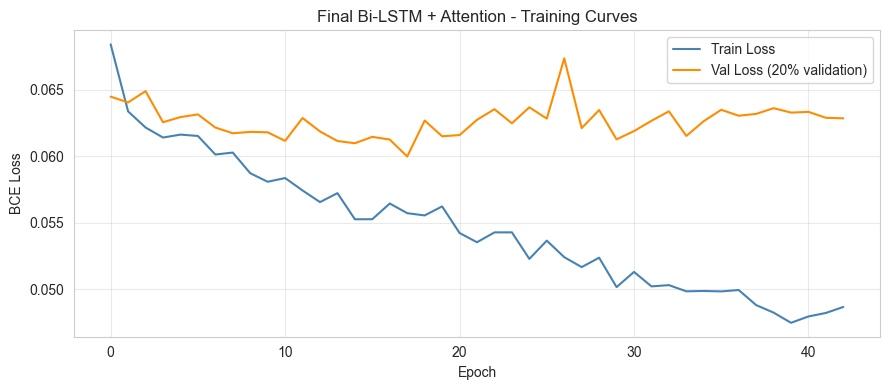

In [9]:
print("\n" + "="*60)
print("TRAINING FINAL MODEL ON FULL TRAINING DATA")
print("="*60)

# Use 90/10 temporal split of train for early stopping(only training)
split_n    = int(len(X_tr_seq) * 0.80)
tr_loader  = make_loader(X_tr_seq[:split_n], X_tr_stat[:split_n], y_tr[:split_n], BATCH_SIZE, shuffle=True)
val_loader = make_loader(X_tr_seq[split_n:], X_tr_stat[split_n:], y_tr[split_n:], BATCH_SIZE, shuffle=False)

final_model = LeptoLSTM_v2(
    seq_input_dim=X_tr_seq.shape[2],
    static_input_dim=X_tr_stat.shape[1]
).to(device)

optimizer = optim.AdamW(final_model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=8, factor=0.5)

best_val  = float('inf')
best_wts  = None
pat_ctr   = 0
t_losses, v_losses = [], []

for epoch in range(N_EPOCHS):
    tl = train_epoch(final_model, tr_loader,  criterion, optimizer)
    vl = eval_epoch(final_model,  val_loader, criterion)
    scheduler.step(vl)
    t_losses.append(tl); v_losses.append(vl)

    if vl < best_val:
        best_val = vl
        best_wts = {k: v.clone() for k, v in final_model.state_dict().items()}
        pat_ctr  = 0
    else:
        pat_ctr += 1
    if pat_ctr >= PATIENCE:
        print(f"Early stopping at epoch {epoch+1}")
        break

final_model.load_state_dict(best_wts)

# Training curve
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(t_losses, label="Train Loss", color="steelblue")
ax.plot(v_losses, label="Val Loss (20% validation)", color="darkorange")
ax.set_xlabel("Epoch"); ax.set_ylabel("BCE Loss")
ax.set_title("Final Bi-LSTM + Attention - Training Curves")
ax.legend(); ax.grid(True, alpha=0.4)
plt.tight_layout(); plt.show()

#### 9. Test Set Evaluation


IMPROVED LSTM (Bi-LSTM + Attention) - TEST RESULTS
  Test ROC-AUC             : 0.9020
  Test Avg. Precision (AP) : 0.9080


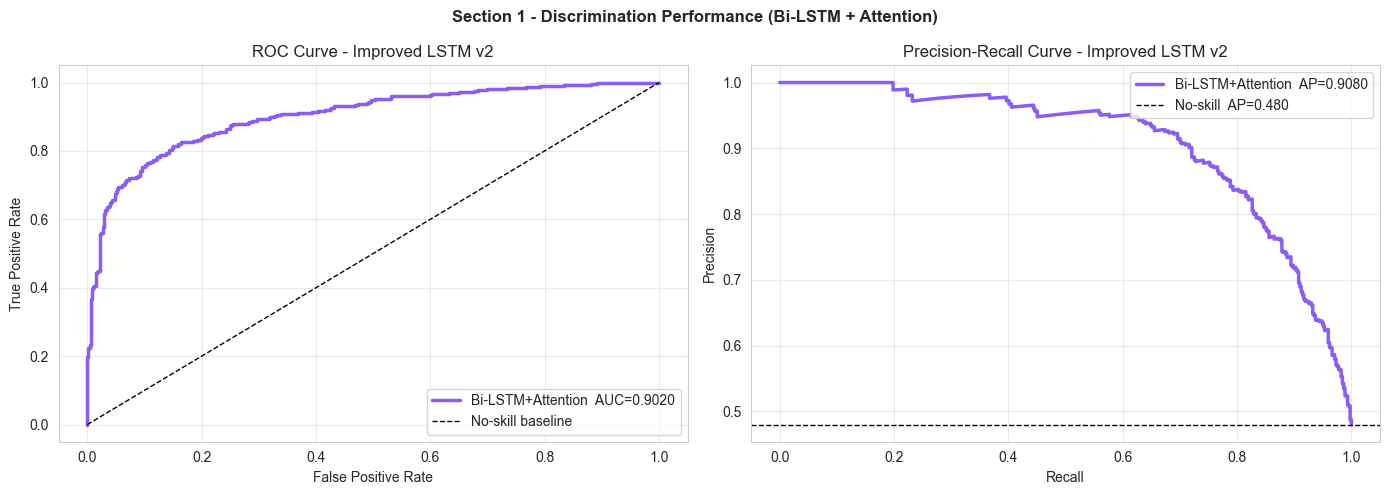

In [10]:

final_probs = predict_proba(final_model, X_te_seq, X_te_stat)

test_auc = roc_auc_score(y_te, final_probs)
test_ap  = average_precision_score(y_te, final_probs)

print(f"\n{'='*60}")
print(f"IMPROVED LSTM (Bi-LSTM + Attention) - TEST RESULTS")
print(f"{'='*60}")
print(f"  Test ROC-AUC             : {test_auc:.4f}")
print(f"  Test Avg. Precision (AP) : {test_ap:.4f}")

# ROC + PR curves
fpr, tpr, _ = roc_curve(y_te, final_probs)
pre, rec, _ = precision_recall_curve(y_te, final_probs)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(fpr, tpr, color="#8B5CF6", lw=2.5, label=f"Bi-LSTM+Attention  AUC={test_auc:.4f}")
axes[0].plot([0,1],[0,1],"k--",lw=1, label="No-skill baseline")
axes[0].set_xlabel("False Positive Rate"); axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve - Improved LSTM v2")
axes[0].legend(loc="lower right"); axes[0].grid(True, alpha=0.4)

axes[1].plot(rec, pre, color="#8B5CF6", lw=2.5, label=f"Bi-LSTM+Attention  AP={test_ap:.4f}")
axes[1].axhline(y=y_te.mean(), color="k", linestyle="--", lw=1, label=f"No-skill  AP={y_te.mean():.3f}")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve - Improved LSTM v2")
axes[1].legend(loc="upper right"); axes[1].grid(True, alpha=0.4)

plt.suptitle("Section 1 - Discrimination Performance (Bi-LSTM + Attention)", fontweight="bold", fontsize=12)
plt.tight_layout(); plt.show()


#### 10. Confusion Matrix & Clinical Metrics


Decision threshold : 0.45
  Sensitivity (HR Recall) : 0.8559  meets 0.80 target
  Specificity             : 0.7609
  PPV (HR Precision)      : 0.7677
  NPV                     : 0.8512
  F1 (High Risk)          : 0.8094

              precision    recall  f1-score   support

    Low Risk       0.85      0.76      0.80       481
   High Risk       0.77      0.86      0.81       444

    accuracy                           0.81       925
   macro avg       0.81      0.81      0.81       925
weighted avg       0.81      0.81      0.81       925



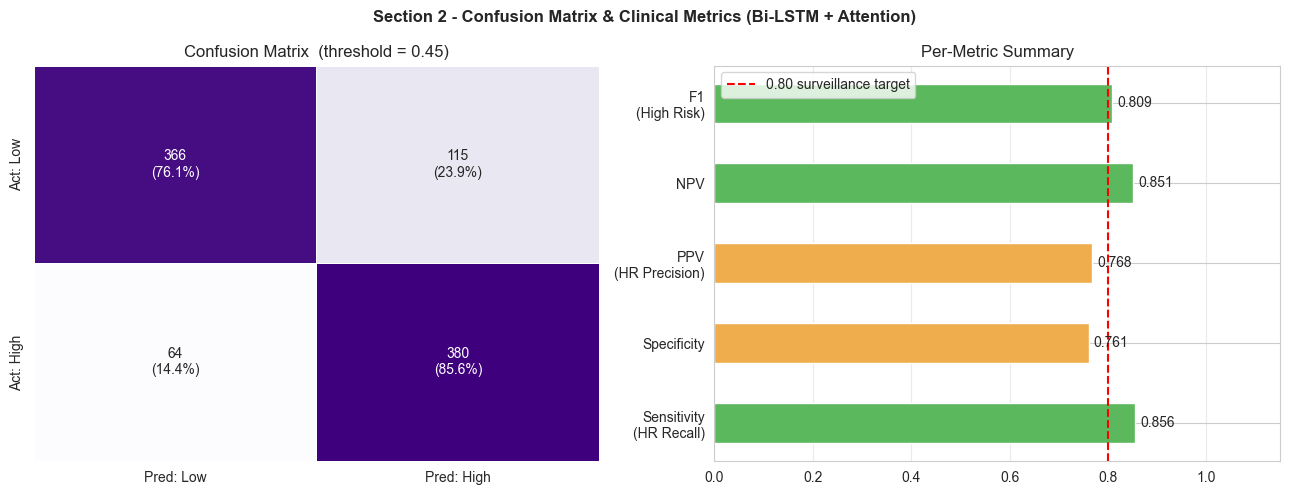

In [11]:


THRESHOLD = 0.45

final_preds = (final_probs >= THRESHOLD).astype(int)
cm = confusion_matrix(y_te, final_preds)
tn, fp, fn, tp = cm.ravel()

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
ppv         = tp / (tp + fp + 1e-9)
npv         = tn / (tn + fn + 1e-9)
f1_hr       = 2 * ppv * sensitivity / (ppv + sensitivity + 1e-9)

print(f"\nDecision threshold : {THRESHOLD:.2f}")
print(f"  Sensitivity (HR Recall) : {sensitivity:.4f}  {'meets 0.80 target' if sensitivity >= 0.80 else 'below 0.80 target'}")
print(f"  Specificity             : {specificity:.4f}")
print(f"  PPV (HR Precision)      : {ppv:.4f}")
print(f"  NPV                     : {npv:.4f}")
print(f"  F1 (High Risk)          : {f1_hr:.4f}")
print()
print(classification_report(y_te, final_preds, target_names=["Low Risk", "High Risk"]))

# Confusion matrix heatmap
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
annot  = [[f"{v}\n({p:.1f}%)" for v, p in zip(rv, rp)] for rv, rp in zip(cm, cm_pct)]
sns.heatmap(cm, annot=annot, fmt="", cmap="Purples", ax=axes[0],
            xticklabels=["Pred: Low", "Pred: High"],
            yticklabels=["Act: Low",  "Act: High"],
            linewidths=0.5, cbar=False)
axes[0].set_title(f"Confusion Matrix  (threshold = {THRESHOLD:.2f})")

metric_names  = ["Sensitivity\n(HR Recall)", "Specificity", "PPV\n(HR Precision)", "NPV", "F1\n(High Risk)"]
metric_values = [sensitivity, specificity, ppv, npv, f1_hr]
bar_c = ["#d9534f" if v < 0.70 else "#f0ad4e" if v < 0.80 else "#5cb85c" for v in metric_values]
axes[1].barh(metric_names, metric_values, color=bar_c, edgecolor="white", height=0.5)
for i, v in enumerate(metric_values):
    axes[1].text(v + 0.01, i, f"{v:.3f}", va="center", fontsize=10)
axes[1].axvline(0.80, color="red", linestyle="--", lw=1.5, label="0.80 surveillance target")
axes[1].set_xlim(0, 1.15); axes[1].legend(); axes[1].grid(axis="x", alpha=0.4)
axes[1].set_title("Per-Metric Summary")

plt.suptitle("Section 2 - Confusion Matrix & Clinical Metrics (Bi-LSTM + Attention)", fontweight="bold")
plt.tight_layout(); plt.show()


#### 11. Summary

In [12]:
# 10. Final Summary Comparison Table
print("\n" + "="*65)
print("RESULTS SUMMARY - Bi-LSTM + Attention (v2)")
print("="*65)

rows = [
    ("Model",                    "Bi-LSTM + Temporal Attention (PyTorch)"),
    ("Sequence length",          f"{SEQ_LEN} months (full annual cycle)"),
    ("Sequence features",        str(len(SEQUENCE_COLS))),
    ("Static features",          str(X_tr_stat.shape[1])),
    ("ROC-AUC",                  f"{test_auc:.4f}"),
    ("Average Precision (AP)",   f"{test_ap:.4f}"),
    (f"Sensitivity  (t={THRESHOLD:.2f})", f"{sensitivity:.4f}"),
    (f"Specificity  (t={THRESHOLD:.2f})", f"{specificity:.4f}"),
    (f"PPV          (t={THRESHOLD:.2f})", f"{ppv:.4f}"),
    (f"F1 High Risk (t={THRESHOLD:.2f})", f"{f1_hr:.4f}"),
    ("CV AUC  (mean ± std)",     f"{np.mean(cv_aucs):.4f} ± {np.std(cv_aucs):.4f}"),
]

for label, value in rows:
    print(f"  {label:<40} {value}")



RESULTS SUMMARY - Bi-LSTM + Attention (v2)
  Model                                    Bi-LSTM + Temporal Attention (PyTorch)
  Sequence length                          12 months (full annual cycle)
  Sequence features                        33
  Static features                          19
  ROC-AUC                                  0.9020
  Average Precision (AP)                   0.9080
  Sensitivity  (t=0.45)                    0.8559
  Specificity  (t=0.45)                    0.7609
  PPV          (t=0.45)                    0.7677
  F1 High Risk (t=0.45)                    0.8094
  CV AUC  (mean ± std)                     0.8218 ± 0.0729


#### 12. Save Model Artifacts

In [13]:
torch.save(final_model.state_dict(), "../../models/lstm_v2_model.pth")
joblib.dump(scaler_seq,  "../../models/lstm_v2_scaler_seq.pkl")
joblib.dump(scaler_stat, "../../models/lstm_v2_scaler_stat.pkl")
joblib.dump(le,          "../../models/lstm_v2_label_encoder.pkl")

# Save metadata
import json
meta = {
    "seq_len":          SEQ_LEN,
    "sequence_cols":    SEQUENCE_COLS,
    "static_cols":      STATIC_COLS,
    "seq_input_dim":    int(X_tr_seq.shape[2]),
    "static_input_dim": int(X_tr_stat.shape[1]),
    "threshold":        THRESHOLD,
    "test_auc":         round(float(test_auc), 4),
    "test_ap":          round(float(test_ap), 4),
    "sensitivity":      round(float(sensitivity), 4),
}
with open("../../models/lstm_v2_meta.json", "w") as f:
    json.dump(meta, f, indent=2)

print("All LSTM v2 artifacts saved:")
print("  models/lstm_v2_model.pth")
print("  models/lstm_v2_scaler_seq.pkl")
print("  models/lstm_v2_scaler_stat.pkl")
print("  models/lstm_v2_label_encoder.pkl")
print("  models/lstm_v2_meta.json")


All LSTM v2 artifacts saved:
  models/lstm_v2_model.pth
  models/lstm_v2_scaler_seq.pkl
  models/lstm_v2_scaler_stat.pkl
  models/lstm_v2_label_encoder.pkl
  models/lstm_v2_meta.json
